# Pertemuan 14 | Peramalan Kadar NO₂ di Kecamatan Sukolilo, Kota Surabaya Menggunakan KNN Regression



## 1. Pendahuluan



Pencemaran udara merupakan salah satu permasalahan lingkungan yang semakin mendapat perhatian, terutama di daerah perkotaan. Salah satu polutan yang sering digunakan sebagai indikator kualitas udara adalah Nitrogen Dioksida (NO₂). Gas ini umumnya berasal dari aktivitas kendaraan bermotor, industri, dan pembakaran bahan bakar fosil.



Kecamatan Sukolilo merupakan salah satu wilayah di Kota Surabaya yang memiliki aktivitas perkotaan cukup tinggi. Oleh karena itu, pemantauan serta peramalan kadar NO₂ menjadi penting untuk membantu pengambilan keputusan dalam pengelolaan lingkungan.



Pada penelitian ini digunakan metode K-Nearest Neighbor Regression (KNN Regression) untuk melakukan peramalan kadar NO₂ berdasarkan data historis yang diperoleh dari satelit Sentinel-5P melalui platform OpenEO.



---



## 2. Tujuan Penelitian

Penelitian ini bertujuan untuk:
1. Mengambil data NO₂ dari satelit Sentinel-5P
2. Menganalisis pola perubahan NO₂ harian
3. Memprediksi kadar NO₂ menggunakan metode KNN Regression
4. Mengevaluasi performa model prediksi

---

## 3. Data dan Sumber Data

Data yang digunakan dalam penelitian ini berasal dari:
- Sentinel-5P Level-2 (NO₂)
- Diakses melalui Copernicus Data Space Ecosystem (OpenEO)
- Format data: NetCDF (.nc)
- Variabel utama: Nitrogen Dioksida (NO₂)

---

## 4. Wilayah Studi

Wilayah penelitian adalah Kecamatan Sukolilo, Kota Surabaya, Indonesia.

Area penelitian difokuskan pada wilayah kecil (subset AOI) untuk mengurangi beban komputasi dan mempercepat proses pengolahan data satelit.

---

## 5. Metodologi

Tahapan penelitian ini meliputi:
1. Pengambilan data menggunakan OpenEO
2. Ekstraksi data NO₂ dari Sentinel-5P
3. Preprocessing data time series
4. Normalisasi data
5. Transformasi menjadi supervised learning
6. Penerapan model KNN Regression
7. Evaluasi menggunakan RMSE dan R²

---

## 6. Pengumpulan Data

### 6.1 Instalasi Library
Langkah pertama yang dilakukan adalah menginstal beberapa library Python yang akan digunakan selama proses penelitian. Library tersebut terdiri dari OpenEO untuk mengakses data Copernicus, NetCDF4 untuk membaca file hasil satelit, Pandas dan NumPy untuk pengolahan data, Matplotlib untuk visualisasi, serta Scikit-Learn untuk proses machine learning menggunakan algoritma KNN Regression.

In [ ]:
!pip install openeo netCDF4 pandas numpy matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.5/345.5 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 88.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 54.1 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


Fungsi :

Menginstal seluruh library yang dibutuhkan dalam proses analisis data dan machine learning.

Tujuan :

Menyiapkan environment agar seluruh proses analisis dapat dijalankan tanpa error.

---
### 6.2 Import Library

Setelah seluruh library berhasil diinstal, langkah berikutnya adalah mengimpor library yang diperlukan ke dalam notebook. Library-library ini akan digunakan pada tahap pengambilan data, preprocessing, visualisasi, hingga pemodelan machine learning.


In [ ]:
import openeo
import netCDF4
import pandas as pd
import numpy as np

Fungsinya adalah :

Mengimpor library yang akan digunakan dalam seluruh proses analisis.


Tujuan :

Mendukung seluruh tahapan analisis mulai dari data hingga model prediksi.

### 6.3 Koneksi ke Copernicus Data Space Ecosystem

Sebelum mengambil data satelit, kita harus terhubung terlebih dahulu ke layanan Copernicus Data Space Ecosystem. Proses autentikasi dilakukan menggunakan akun Copernicus yang telah dibuat sebelumnya. Setelah berhasil login, Python dapat mengakses berbagai dataset satelit yang tersedia.

In [ ]:
connection = openeo.connect(
    "openeo.dataspace.copernicus.eu"
).authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=RUBZ-ASNK 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


Output Koneksi ke Copernicus:

Setelah menjalankan kode koneksi OpenEO, sistem akan menampilkan tautan autentikasi yang harus dibuka melalui browser. Pengguna kemudian melakukan login menggunakan akun Copernicus Data Space Ecosystem yang telah dibuat sebelumnya.

Penjelasan Output:

Baris pertama menunjukkan URL autentikasi yang harus dibuka untuk proses login.
Setelah login berhasil, sistem menampilkan pesan Authorized successfully yang menandakan akun telah terverifikasi.
Pesan Authenticated using device code flow menunjukkan bahwa proses autentikasi menggunakan metode Device Code Authentication, yaitu mekanisme login yang umum digunakan pada Jupyter Notebook atau aplikasi yang tidak memiliki halaman login bawaan.

### 6.4 Menentukan Area Penelitian

Karena penelitian difokuskan pada Kecamatan Sukolilo, Kota Surabaya, maka diperlukan Area of Interest (AOI) yang merepresentasikan batas wilayah penelitian. Area ini ditentukan menggunakan koordinat geografis berbentuk polygon.

Tujuan pembatasan area adalah agar data yang diambil hanya berasal dari wilayah penelitian sehingga proses pengambilan data menjadi lebih cepat dan efisien.

In [ ]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [112.82, -7.28],
            [112.74, -7.28],
            [112.74, -7.35],
            [112.82, -7.35],
            [112.82, -7.28]
        ]
    ]
}

### 6.5 Mengambil Dataset NO₂ dari Sentinel-5P

Setelah area penelitian ditentukan, langkah berikutnya adalah mengambil data Nitrogen Dioksida (NO₂) dari satelit Sentinel-5P. Dataset yang digunakan adalah SENTINEL_5P_L2 dengan parameter band NO₂.

Data diambil untuk periode 1 Juni 2024 hingga 1 Juni 2025 sehingga diperoleh data time series harian selama satu tahun.

In [ ]:
s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2024-06-01", "2025-06-01"],
    spatial_extent={
        "west": 112.74,
        "south": -7.35,
        "east": 112.82,
        "north": -7.28
    },
    bands=["NO2"]
)

### 6.6 Agregasi Data Harian

Setelah data NO₂ berhasil diambil dari Sentinel-5P, langkah berikutnya adalah melakukan agregasi temporal harian. Proses ini bertujuan untuk mengubah data yang mungkin memiliki lebih dari satu pengamatan dalam satu hari menjadi satu nilai rata-rata per hari.

Dengan demikian, data yang dihasilkan akan berbentuk time series harian sehingga lebih sesuai untuk proses peramalan.

In [ ]:
s5p_daily = s5post.aggregate_temporal_period(
    period="day",
    reducer="mean"
)

### 6.7 Menjalankan Proses Pengambilan Data

Setelah dataset dan periode waktu ditentukan, proses pengambilan data dijalankan menggunakan sistem cloud milik Copernicus. Hasil proses ini akan disimpan dalam format NetCDF (.nc) yang umum digunakan untuk data satelit.

In [ ]:
job = s5p_daily.execute_batch(
    title="NO2_Sukolilo_Surabaya",
    outputfile="NO2_Sukolilo_Surabaya.nc"
)

0:00:00 Job 'j-260603081655474fafbaacd042d05db6': send 'start'
0:00:33 Job 'j-260603081655474fafbaacd042d05db6': queued (progress 0%)
0:00:39 Job 'j-260603081655474fafbaacd042d05db6': queued (progress 0%)
0:00:45 Job 'j-260603081655474fafbaacd042d05db6': queued (progress 0%)
0:00:53 Job 'j-260603081655474fafbaacd042d05db6': queued (progress 0%)
0:01:03 Job 'j-260603081655474fafbaacd042d05db6': queued (progress 0%)
0:01:16 Job 'j-260603081655474fafbaacd042d05db6': running (progress N/A)
0:01:31 Job 'j-260603081655474fafbaacd042d05db6': running (progress N/A)
0:01:51 Job 'j-260603081655474fafbaacd042d05db6': running (progress N/A)
0:02:15 Job 'j-260603081655474fafbaacd042d05db6': running (progress N/A)
0:02:45 Job 'j-260603081655474fafbaacd042d05db6': running (progress N/A)
0:03:23 Job 'j-260603081655474fafbaacd042d05db6': running (progress N/A)
0:04:09 Job 'j-260603081655474fafbaacd042d05db6': running (progress N/A)
0:05:08 Job 'j-260603081655474fafbaacd042d05db6': finished (progress 10

## 7. PreProcessing Data

### 7.1 Membaca File NetCDF

Setelah proses pengambilan data selesai, file NetCDF dibaca menggunakan library NetCDF4. Tahap ini bertujuan untuk melihat struktur data yang tersimpan di dalam file satelit.

In [ ]:

import netCDF4

file_path = "NO2_Sukolilo_Surabaya.nc"

ds = netCDF4.Dataset(file_path)

print("Variabel dalam file:")
print(ds.variables.keys())

Variabel dalam file:
dict_keys(['t', 'x', 'y', 'crs', 'NO2'])


### 7.2 Mengambil Variabel NO₂ dan Waktu

File NetCDF memiliki beberapa variabel. Pada penelitian ini hanya digunakan variabel waktu (t) dan konsentrasi Nitrogen Dioksida (NO2) sebagai objek analisis.

In [ ]:
no2 = ds.variables["NO2"][:]

time = ds.variables["t"][:]

time_units = ds.variables["t"].units

dates = netCDF4.num2date(
    time,
    units=time_units
)


### 7.3 Melihat Struktur Data

Sebelum melakukan preprocessing, perlu dilakukan pemeriksaan bentuk data untuk mengetahui jumlah record dan ukuran grid yang diperoleh dari satelit.

In [ ]:
print(type(no2))

print(len(no2))

print(len(no2[0]))

print(len(no2[0][0]))

print(no2[0][0][0])

<class 'numpy.ma.MaskedArray'>
362
3
2
2.0348361e-05


Analisis

Berdasarkan hasil di atas diketahui bahwa data NO₂ berbentuk MaskedArray yang memungkinkan adanya missing value. Dataset terdiri dari 362 record harian dengan ukuran grid spasial 3 × 2 untuk setiap tanggal pengamatan.

### 7.4 Menampilkan Contoh Data

Untuk memahami isi dataset lebih lanjut, beberapa data pertama ditampilkan. Tahap ini bertujuan untuk mengidentifikasi keberadaan missing value yang biasanya ditandai dengan simbol --.

In [ ]:
print("Contoh data pertama:")

for i in range(5):
    print(no2[i])

Contoh data pertama:
[[2.0348361431388184e-05 3.136975283268839e-05]
 [2.7731824957299978e-05 3.473311153356917e-05]
 [2.7731824957299978e-05 3.1783019949216396e-05]]
[[-- --]
 [-- --]
 [-- --]]
[[5.1556835387600586e-05 5.1556835387600586e-05]
 [3.986679803347215e-05 3.986679803347215e-05]
 [3.986679803347215e-05 5.205026172916405e-05]]
[[4.988355067325756e-05 3.548788299667649e-05]
 [4.988355067325756e-05 3.152710269205272e-05]
 [6.797500827815384e-05 3.152710269205272e-05]]
[[4.208485916024074e-05 3.413308513700031e-05]
 [4.075754259247333e-05 3.2486314012203366e-05]
 [4.075754259247333e-05 4.075754259247333e-05]]


### 7.5 Mengatasi Missing Value Menggunakan Interpolasi Linear

Data satelit sering mengandung nilai kosong akibat gangguan pengamatan. Oleh karena itu dilakukan interpolasi linear agar nilai yang hilang dapat diisi berdasarkan nilai sebelum dan sesudahnya.

In [ ]:
import numpy as np
import pandas as pd

no2_nan = no2.filled(np.nan)

no2_filled = np.zeros(no2_nan.shape)

for i in range(no2_nan.shape[1]):
    for j in range(no2_nan.shape[2]):

        series = pd.Series(no2_nan[:, i, j])

        series = series.interpolate(
            method='linear',
            limit_direction='both'
        )

        series = series.bfill().ffill()

        no2_filled[:, i, j] = series.values

In [ ]:
print(np.isnan(no2_filled).sum())

0


### 7.6 Mengubah Menjadi Data Time Series Harian

Karena setiap hari masih memiliki beberapa nilai grid, maka seluruh nilai dalam satu hari dirata-ratakan sehingga menghasilkan satu nilai NO₂ untuk setiap tanggal.

In [ ]:
new_dates = []
new_no2 = []

for i in range(len(dates)):

    new_dates.append(
        dates[i].strftime('%Y-%m-%d')
    )

    new_no2.append(
        np.mean(no2_filled[i])
    )

### 7.7 Membentuk DataFrame

Data hasil rata-rata harian kemudian dibentuk menjadi DataFrame yang terdiri dari kolom tanggal dan nilai NO₂.

In [ ]:
df = pd.DataFrame({
    "date": new_dates,
    "NO2": new_no2
})

print(df.head())

print()

df.info()

         date       NO2
0  2024-06-01  0.000029
1  2024-06-02  0.000037
2  2024-06-03  0.000046
3  2024-06-04  0.000044
4  2024-06-05  0.000038

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 362 entries, 0 to 361
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    362 non-null    object 
 1   NO2     362 non-null    float64
dtypes: float64(1), object(1)
memory usage: 5.8+ KB


### 7.8 Menyimpan Data ke CSV

Dataset hasil preprocessing disimpan dalam format CSV agar lebih mudah digunakan pada tahap analisis berikutnya.

In [ ]:
df.to_csv(
    "NO2_Sukolilo_Surabaya_timeseries.csv",
    index=False
)

### 7.9 Pemeriksaan Missing Date

Setelah data berbentuk time series harian, dilakukan pengecekan apakah terdapat tanggal yang hilang.

In [ ]:
df['date'] = pd.to_datetime(df['date'])

start_date = df['date'].min()
end_date = df['date'].max()

full_range = pd.date_range(
    start=start_date,
    end=end_date,
    freq='D'
)

missing_dates = full_range.difference(df['date'])

print("Jumlah hari missing:", len(missing_dates))
print(missing_dates)

Jumlah hari missing: 3
DatetimeIndex(['2024-08-12', '2025-01-30', '2025-01-31'], dtype='datetime64[ns]', freq=None)


Analisis

Hasil pengecekan menunjukkan masih terdapat 3 tanggal yang hilang sehingga perlu dilakukan interpolasi kembali agar data time series menjadi lengkap.

### 7.10 Interpolasi Missing Date

Tanggal yang hilang diperbaiki menggunakan interpolasi berbasis waktu (time interpolation).

In [ ]:
df = df.sort_values('date')

full_range = pd.date_range(
    start=df['date'].min(),
    end=df['date'].max(),
    freq='D'
)

df = df.set_index('date').reindex(full_range)

df.index.name = 'date'

df['NO2'] = df['NO2'].interpolate(
    method='time'
)

df['NO2'] = df['NO2'].bfill().ffill()

df = df.reset_index()

df.rename(
    columns={'index': 'date'},
    inplace=True
)

In [ ]:
full_range = pd.date_range(
    start=df['date'].min(),
    end=df['date'].max(),
    freq='D'
)

missing_dates = full_range.difference(df['date'])

print("Jumlah hari missing:", len(missing_dates))
print(missing_dates)

Jumlah hari missing: 0
DatetimeIndex([], dtype='datetime64[ns]', freq='D')


### 7.11 Menyimpan Dataset Final

Setelah seluruh missing value berhasil diperbaiki, dataset final disimpan kembali dan siap digunakan untuk proses pemodelan.

In [ ]:
df.to_csv(
    "NO2_Sukolilo_Surabaya_timeseries_final.csv",
    index=False
)

print(df.head())

print()

df.info()

        date       NO2
0 2024-06-01  0.000029
1 2024-06-02  0.000037
2 2024-06-03  0.000046
3 2024-06-04  0.000044
4 2024-06-05  0.000038

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    365 non-null    datetime64[ns]
 1   NO2     365 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 5.8 KB


# 8. Modeling Menggunakan KNN Regression

Setelah proses preprocessing selesai dilakukan, tahap berikutnya adalah membangun model prediksi menggunakan algoritma K-Nearest Neighbors (KNN) Regression. Tujuan dari tahap ini adalah memprediksi konsentrasi NO₂ pada hari berikutnya berdasarkan data historis beberapa hari sebelumnya.

Pada penelitian ini digunakan dua skenario, yaitu menggunakan 4 hari sebelumnya dan 10 hari sebelumnya sebagai fitur prediksi. Kedua skenario tersebut dibandingkan untuk mengetahui jumlah lag yang memberikan performa terbaik.

---

## 8.1 Normalisasi Data

Sebelum membangun model KNN, data perlu dinormalisasi terlebih dahulu. Hal ini dilakukan karena algoritma KNN menggunakan perhitungan jarak antar data. Jika skala data terlalu besar atau tidak seragam, maka hasil perhitungan jarak dapat menjadi kurang optimal.

Metode normalisasi yang digunakan adalah Min-Max Scaling, yaitu mengubah rentang data menjadi 0 hingga 1.



In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df['NO2_scaled'] = scaler.fit_transform(
    df[['NO2']]
)

print(df.head())
print()
df.info()

        date       NO2  NO2_scaled
0 2024-06-01  0.000029    0.181199
1 2024-06-02  0.000037    0.247102
2 2024-06-03  0.000046    0.313004
3 2024-06-04  0.000044    0.301945
4 2024-06-05  0.000038    0.255899

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        365 non-null    datetime64[ns]
 1   NO2         365 non-null    float64       
 2   NO2_scaled  365 non-null    float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 8.7 KB



### Hasil

Output akan menampilkan kolom baru bernama `NO2_scaled` yang berisi data hasil normalisasi.

---

## 8.2 Membuat Fungsi Transformasi Time Series

Data time series tidak dapat langsung digunakan oleh algoritma KNN karena model membutuhkan data dalam bentuk fitur dan target. Oleh karena itu dilakukan transformasi data menggunakan metode lag.

Pada metode ini, nilai NO₂ beberapa hari sebelumnya digunakan sebagai fitur untuk memprediksi nilai NO₂ pada hari berikutnya.



In [ ]:
import pandas as pd

def create_supervised(data, n_lag=4):

    df_supervised = pd.DataFrame()

    for i in range(n_lag, 0, -1):
        df_supervised[f'NO2(t-{i})'] = data.shift(i)

    df_supervised['NO2(t)'] = data

    df_supervised.dropna(inplace=True)

    return df_supervised


### Penjelasan

Fungsi `create_supervised()` digunakan untuk mengubah data time series menjadi bentuk supervised learning.

Sebagai contoh:

| t-4 | t-3 | t-2 | t-1 | t |
|------|------|------|------|------|
| 0.20 | 0.18 | 0.22 | 0.25 | 0.24 |

Empat nilai sebelumnya digunakan sebagai fitur untuk memprediksi nilai pada hari ke-t.

---

## 8.3 Membentuk Dataset Lag 4 Hari

Pada skenario pertama digunakan empat hari sebelumnya sebagai fitur prediksi.



In [ ]:
supervised_df = create_supervised(
    df['NO2_scaled'],
    n_lag=4
)

print(supervised_df.head())
print()
print(supervised_df.shape)

   NO2(t-4)  NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)
4  0.181199  0.247102  0.313004  0.301945  0.255899
5  0.247102  0.313004  0.301945  0.255899  0.155689
6  0.313004  0.301945  0.255899  0.155689  0.233893
7  0.301945  0.255899  0.155689  0.233893  0.132820
8  0.255899  0.155689  0.233893  0.132820  0.130400

(361, 5)



### Penjelasan

Dataset ini memiliki empat fitur:

- NO2(t-4)
- NO2(t-3)
- NO2(t-2)
- NO2(t-1)

dan satu target:

- NO2(t)

---

## 8.4 Membentuk Dataset Lag 10 Hari

Pada skenario kedua digunakan sepuluh hari sebelumnya sebagai fitur prediksi.



In [ ]:
supervised_df10 = create_supervised(
    df['NO2_scaled'],
    n_lag=10
)

print(supervised_df10.head())
print()
print(supervised_df10.shape)

    NO2(t-10)  NO2(t-9)  NO2(t-8)  NO2(t-7)  NO2(t-6)  NO2(t-5)  NO2(t-4)  \
10   0.181199  0.247102  0.313004  0.301945  0.255899  0.155689  0.233893   
11   0.247102  0.313004  0.301945  0.255899  0.155689  0.233893  0.132820   
12   0.313004  0.301945  0.255899  0.155689  0.233893  0.132820  0.130400   
13   0.301945  0.255899  0.155689  0.233893  0.132820  0.130400  0.195761   
14   0.255899  0.155689  0.233893  0.132820  0.130400  0.195761  0.096596   

    NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)  
10  0.132820  0.130400  0.195761  0.096596  
11  0.130400  0.195761  0.096596  0.115126  
12  0.195761  0.096596  0.115126  0.364547  
13  0.096596  0.115126  0.364547  0.186439  
14  0.115126  0.364547  0.186439  0.139615  

(355, 11)




### Penjelasan

Dataset ini memiliki sepuluh fitur historis yang digunakan untuk memprediksi nilai NO₂ pada hari berikutnya.

Tujuannya adalah untuk mengetahui apakah penggunaan data historis yang lebih panjang mampu meningkatkan performa model.

---

## 8.5 Membangun Fungsi Training KNN Regression

Agar proses pelatihan lebih mudah dilakukan pada kedua skenario, dibuat fungsi khusus untuk melakukan training, testing, prediksi, dan evaluasi model.





In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [ ]:
def train_knn(df_supervised, model_name=""):

    X = df_supervised.drop(
        columns=['NO2(t)']
    ).values

    y = df_supervised['NO2(t)'].values

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        shuffle=False
    )

    knn = KNeighborsRegressor(
        n_neighbors=5
    )

    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    mse = mean_squared_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_test,
        y_pred
    )

    print(f"\n=== {model_name} ===")
    print(f"Train Size: {len(X_train)}")
    print(f"Test Size : {len(X_test)}")
    print(f"RMSE      : {rmse:.6f}")
    print(f"R² Score  : {r2:.4f}")

    return y_test, y_pred

### Penjelasan

Pada fungsi ini dilakukan beberapa proses:

1. Memisahkan fitur dan target.
2. Membagi data training dan testing dengan rasio 80:20.
3. Membangun model KNN Regression.
4. Melatih model menggunakan data training.
5. Melakukan prediksi terhadap data testing.
6. Menghitung nilai RMSE dan R² Score.

---

## 8.6 Training Model KNN Menggunakan 4 Hari Sebelumnya

Model pertama dibangun menggunakan empat hari sebelumnya sebagai fitur prediksi.




In [ ]:
y_test_4, y_pred_4 = train_knn(
    supervised_df,
    "KNN - 4 Hari Sebelumnya"
)

y_test_10, y_pred_10 = train_knn(
    supervised_df10,
    "KNN - 10 Hari Sebelumnya"
)


=== KNN - 4 Hari Sebelumnya ===
Train Size: 288
Test Size : 73
RMSE      : 0.054343
R² Score  : 0.7310

=== KNN - 10 Hari Sebelumnya ===
Train Size: 284
Test Size : 71
RMSE      : 0.073509
R² Score  : 0.5007


### Penjelasan

Model akan mencari pola hubungan antara empat hari sebelumnya dengan nilai NO₂ pada hari berikutnya.

---

## 8.7 Visualisasi Hasil Prediksi KNN Menggunakan 4 Hari Sebelumnya

Setelah model KNN berhasil dilatih, langkah berikutnya adalah melakukan visualisasi hasil prediksi. Visualisasi ini bertujuan untuk membandingkan nilai aktual NO₂ dengan nilai hasil prediksi yang dihasilkan oleh model KNN.

Dengan membandingkan kedua garis pada grafik, kita dapat melihat apakah model mampu mengikuti pola perubahan data yang sebenarnya. Semakin dekat posisi garis prediksi terhadap garis aktual, maka semakin baik kemampuan model dalam melakukan prediksi.

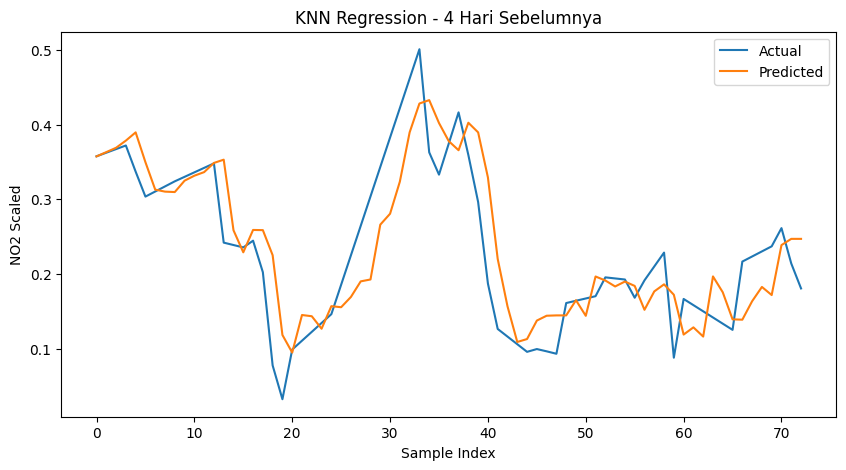

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,5))

plt.plot(
    np.arange(len(y_test_4)),
    y_test_4,
    label="Actual"
)

plt.plot(
    np.arange(len(y_pred_4)),
    y_pred_4,
    label="Predicted"
)

plt.title("KNN Regression - 4 Hari Sebelumnya")

plt.xlabel("Sample Index")

plt.ylabel("NO2 Scaled")

plt.legend()

plt.show()

### Fungsi Kode

Kode di atas digunakan untuk membuat grafik perbandingan antara data aktual dan data hasil prediksi model KNN yang menggunakan empat hari sebelumnya sebagai fitur prediksi.

### Tujuan Visualisasi

Visualisasi dilakukan untuk:

1. Melihat kemampuan model dalam mengikuti pola perubahan konsentrasi NO₂.
2. Membandingkan nilai prediksi dengan nilai aktual secara langsung.
3. Mengidentifikasi bagian data yang berhasil diprediksi dengan baik maupun yang masih memiliki selisih cukup besar.
4. Mempermudah interpretasi hasil model dibandingkan hanya melihat nilai RMSE dan R² Score.

### Penjelasan Grafik

Pada grafik yang dihasilkan terdapat dua garis, yaitu:

- **Actual** menunjukkan nilai konsentrasi NO₂ sebenarnya pada data pengujian.
- **Predicted** menunjukkan nilai konsentrasi NO₂ hasil prediksi model KNN.

Sumbu **X** menunjukkan urutan data pengujian (*sample index*), sedangkan sumbu **Y** menunjukkan nilai konsentrasi NO₂ yang telah dinormalisasi (*scaled value*).

### Analisis Hasil

Berdasarkan grafik yang dihasilkan, terlihat bahwa garis prediksi mampu mengikuti sebagian besar pola pergerakan garis aktual. Meskipun terdapat beberapa titik yang tidak tepat sama, secara umum model berhasil menangkap tren perubahan konsentrasi NO₂ pada wilayah penelitian.

Hasil visualisasi ini juga sejalan dengan nilai evaluasi yang diperoleh sebelumnya, yaitu:

- RMSE = **0.054343**
- R² Score = **0.7310**

Nilai RMSE yang relatif kecil menunjukkan bahwa rata-rata kesalahan prediksi model cukup rendah. Selain itu, nilai R² sebesar 0.7310 menunjukkan bahwa model mampu menjelaskan sekitar 73,10% variasi data konsentrasi NO₂ pada data pengujian.

Dengan demikian, model KNN yang menggunakan empat hari sebelumnya sebagai fitur prediksi dapat dikatakan memiliki performa yang cukup baik dalam memprediksi konsentrasi NO₂ harian di Kecamatan Sukolilo, Kota Surabaya.

## 8.8 Visualisasi Hasil Prediksi KNN Menggunakan 10 Hari Sebelumnya

Setelah model KNN dengan skenario sepuluh hari sebelumnya berhasil dilatih, langkah berikutnya adalah melakukan visualisasi hasil prediksi. Visualisasi ini bertujuan untuk membandingkan nilai aktual NO₂ dengan nilai hasil prediksi yang dihasilkan oleh model KNN menggunakan informasi dari sepuluh hari sebelumnya.

Dengan membandingkan kedua garis pada grafik, dapat diamati sejauh mana model mampu mengikuti pola perubahan konsentrasi NO₂ yang sebenarnya. Selain itu, visualisasi ini juga digunakan untuk membandingkan performa model 10 hari sebelumnya dengan model 4 hari sebelumnya yang telah dibangun pada tahap sebelumnya.

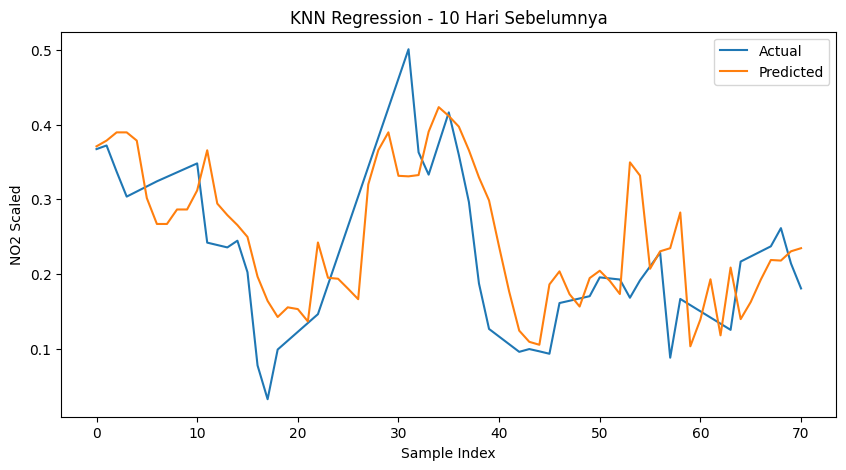

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    np.arange(len(y_test_10)),
    y_test_10,
    label="Actual"
)

plt.plot(
    np.arange(len(y_pred_10)),
    y_pred_10,
    label="Predicted"
)

plt.title("KNN Regression - 10 Hari Sebelumnya")

plt.xlabel("Sample Index")

plt.ylabel("NO2 Scaled")

plt.legend()

plt.show()

### Fungsi Kode

Kode di atas digunakan untuk membuat grafik perbandingan antara data aktual dan data hasil prediksi model KNN yang menggunakan sepuluh hari sebelumnya sebagai fitur prediksi.

### Tujuan Visualisasi

Visualisasi dilakukan untuk:

1. Melihat kemampuan model dalam mengikuti pola perubahan konsentrasi NO₂.
2. Membandingkan nilai prediksi dengan nilai aktual secara langsung.
3. Mengidentifikasi bagian data yang berhasil diprediksi dengan baik maupun yang masih memiliki selisih cukup besar.
4. Mengevaluasi pengaruh penggunaan sepuluh hari data historis terhadap performa model KNN.
5. Membandingkan hasil model 10 hari sebelumnya dengan model 4 hari sebelumnya.

### Penjelasan Grafik

Pada grafik yang dihasilkan terdapat dua garis, yaitu:

- **Actual** menunjukkan nilai konsentrasi NO₂ sebenarnya pada data pengujian.
- **Predicted** menunjukkan nilai konsentrasi NO₂ hasil prediksi model KNN.

Sumbu **X** menunjukkan urutan data pengujian (*sample index*), sedangkan sumbu **Y** menunjukkan nilai konsentrasi NO₂ yang telah dinormalisasi (*scaled value*).

### Analisis Hasil

Berdasarkan grafik yang dihasilkan, terlihat bahwa garis prediksi masih mampu mengikuti pola umum perubahan konsentrasi NO₂. Namun, pada beberapa bagian terdapat perbedaan yang lebih besar antara garis prediksi dan garis aktual dibandingkan model yang menggunakan empat hari sebelumnya.

Hasil visualisasi ini sejalan dengan nilai evaluasi yang diperoleh sebelumnya, yaitu:

- RMSE = **0.073509**
- R² Score = **0.5007**

Nilai RMSE yang lebih besar menunjukkan bahwa kesalahan prediksi model meningkat dibandingkan skenario empat hari sebelumnya. Selain itu, nilai R² sebesar 0.5007 menunjukkan bahwa model hanya mampu menjelaskan sekitar 50,07% variasi data konsentrasi NO₂ pada data pengujian.

Berdasarkan perbandingan kedua skenario, model KNN yang menggunakan empat hari sebelumnya menghasilkan performa yang lebih baik dibandingkan model yang menggunakan sepuluh hari sebelumnya. Hal ini mengindikasikan bahwa perubahan konsentrasi NO₂ di Kecamatan Sukolilo lebih dipengaruhi oleh kondisi beberapa hari terakhir dibandingkan data historis yang terlalu panjang.

## 8.9 Visualisasi Time Series Konsentrasi NO₂ Harian

Setelah seluruh proses preprocessing selesai dilakukan, langkah berikutnya adalah membuat visualisasi data time series. Visualisasi ini bertujuan untuk melihat pola perubahan konsentrasi Nitrogen Dioksida (NO₂) di Kecamatan Sukolilo, Kota Surabaya selama periode pengamatan.

Melalui grafik time series, kita dapat mengamati tren, fluktuasi, serta perubahan konsentrasi NO₂ dari waktu ke waktu. Tahap ini penting dilakukan sebelum membangun model prediksi karena dapat membantu memahami karakteristik data yang akan digunakan.

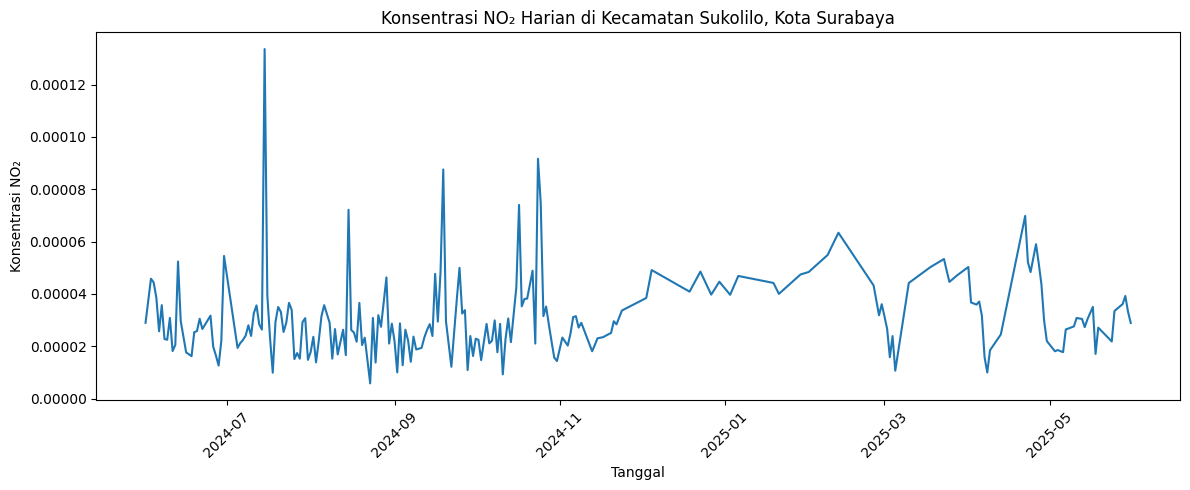

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df["date"], df["NO2"])

plt.title("Konsentrasi NO₂ Harian di Kecamatan Sukolilo, Kota Surabaya")
plt.xlabel("Tanggal")
plt.ylabel("Konsentrasi NO₂")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Fungsi Kode

Kode di atas digunakan untuk membuat grafik time series yang menampilkan perubahan konsentrasi NO₂ harian berdasarkan tanggal pengamatan.

### Tujuan Visualisasi

Visualisasi dilakukan untuk:

1. Melihat pola perubahan konsentrasi NO₂ selama periode pengamatan.
2. Mengidentifikasi adanya tren kenaikan atau penurunan konsentrasi NO₂.
3. Mengamati fluktuasi data dari hari ke hari.
4. Memastikan data telah siap digunakan untuk proses pemodelan time series.
5. Memberikan gambaran awal mengenai karakteristik data sebelum dilakukan prediksi menggunakan algoritma KNN Regression.

### Penjelasan Grafik

Pada grafik yang dihasilkan:

- Sumbu **X** menunjukkan tanggal pengamatan.
- Sumbu **Y** menunjukkan nilai konsentrasi NO₂ harian.
- Setiap titik pada grafik merepresentasikan rata-rata konsentrasi NO₂ pada satu hari tertentu di wilayah Kecamatan Sukolilo.

Garis yang terbentuk menunjukkan perubahan konsentrasi NO₂ dari waktu ke waktu selama periode pengamatan.

### Analisis Hasil

Berdasarkan grafik time series yang dihasilkan, terlihat bahwa konsentrasi NO₂ mengalami fluktuasi dari hari ke hari. Fluktuasi ini menunjukkan bahwa tingkat pencemaran udara tidak selalu berada pada nilai yang sama, melainkan dipengaruhi oleh berbagai faktor seperti aktivitas transportasi, aktivitas industri, kondisi cuaca, serta faktor lingkungan lainnya.

Selain itu, tidak terlihat adanya nilai yang hilang (*missing value*) pada grafik, yang menunjukkan bahwa proses preprocessing dan interpolasi data telah berhasil dilakukan dengan baik. Dengan demikian, dataset telah siap digunakan pada tahap pemodelan menggunakan algoritma KNN Regression.

# FINAL

## Menyimpan data CSV

In [ ]:
df.to_csv("NO2_Sukolilo_Surabaya.csv", index=False)

print("CSV berhasil disimpan")

CSV berhasil disimpan
